In [1]:
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

Transformações - Realce

In [2]:
def log_transform_realce(c, r):
    s = c*np.log(1+r)
    return s

def pot_transform_realce(c, r, gamma):
    s = c*np.power(r, gamma)
    return s

In [3]:
img_308 = Image.open("./images/Fig0308(a)(fractured_spine).tif").convert("L")
img_309 = Image.open("./images/Fig0309(a)(washed_out_aerial_image).tif").convert("L")

Imagem 3.8

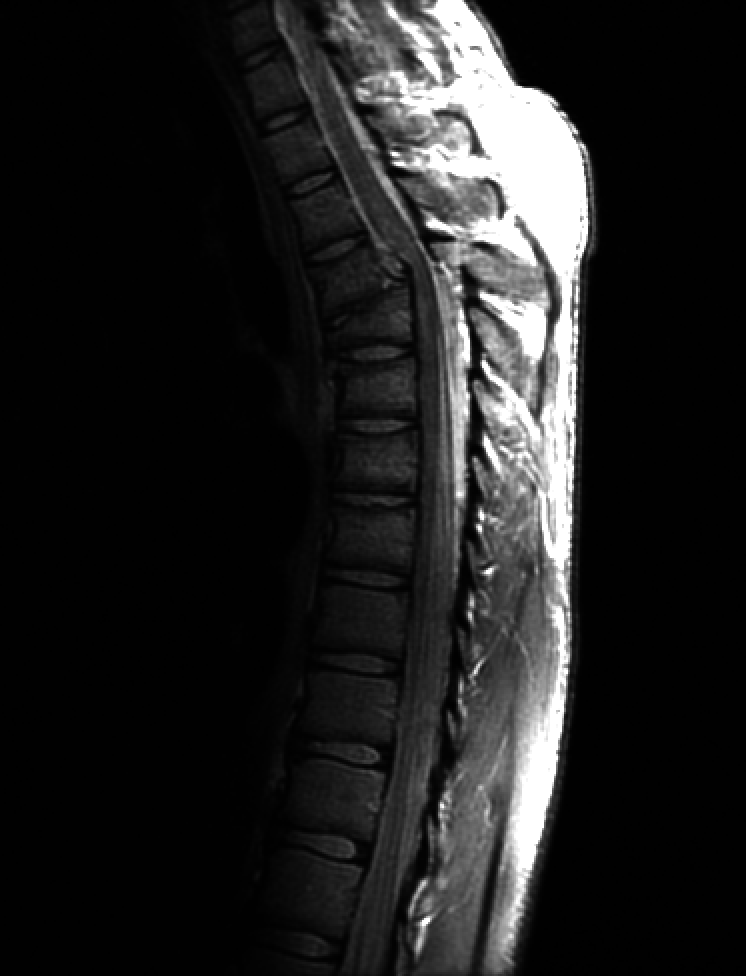

In [4]:
img_308

In [5]:
img_308_g_array = np.array(img_308)
print(f"{type(img_308_g_array)}, {type(img_308)}")
print(f"{img_308_g_array.shape}, {img_308.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(976, 746), (746, 976)


A imagem necessita de uma normalização prévia, isso porque as imagens digitais se aplicadas diretamente na função com um r [0, 255]:

```py
pot_transform_realce(c, r, gamma):
    s = c*np.power(r, gamma)
    return s
```

Resulta em um `s` de no máximo (com gamma=0.5), $ r=255, 1*\sqrt{255, 0.5} \approx 15.97 $, isso implica que os valores de saída possíveis de `s` para um gamma = 0.5 é no intervalo [0, 15.97].

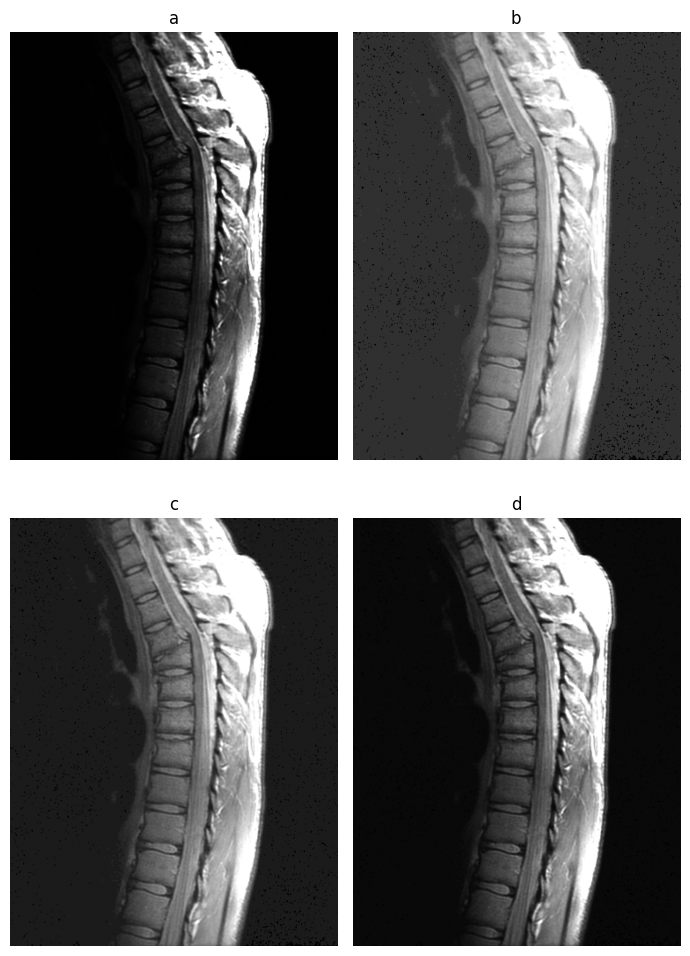

In [6]:
# Applying gamma realce

img_308_normalized = img_308_g_array.astype(np.float32) / 255.0 # Normalizar entre 0 e 1.

img_308_realced_06 = pot_transform_realce(c=1, r=img_308_normalized, gamma=0.6)
img_308_realced_04 = pot_transform_realce(c=1, r=img_308_normalized, gamma=0.4)
img_308_realced_03 = pot_transform_realce(c=1, r=img_308_normalized, gamma=0.3)

# Desnormalizar
img_308_realced_03 = img_308_realced_03 * 255.0
img_308_realced_04 = img_308_realced_04 * 255.0
img_308_realced_06 = img_308_realced_06 * 255.0

images = [img_308, img_308_realced_03, img_308_realced_04, img_308_realced_06]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(7, 10))
axes = axes.flatten()
name_figures = ["a", "b", "c", "d"]
for i, img_np in enumerate(images):
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(name_figures[i])
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("panel_figures_3_8.tif")
plt.show()

Imagem 3.9

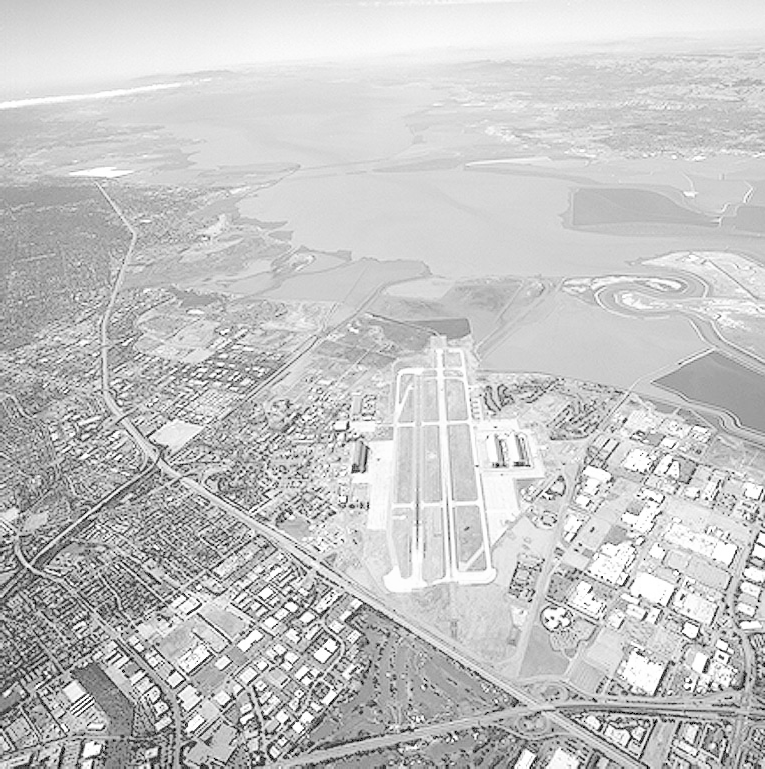

In [7]:
img_309

In [8]:
img_309_g_array = np.array(img_309)
print(f"{type(img_309_g_array)}, {type(img_309)}")
print(f"{img_309_g_array.shape}, {img_309.size}")

<class 'numpy.ndarray'>, <class 'PIL.Image.Image'>
(769, 765), (765, 769)


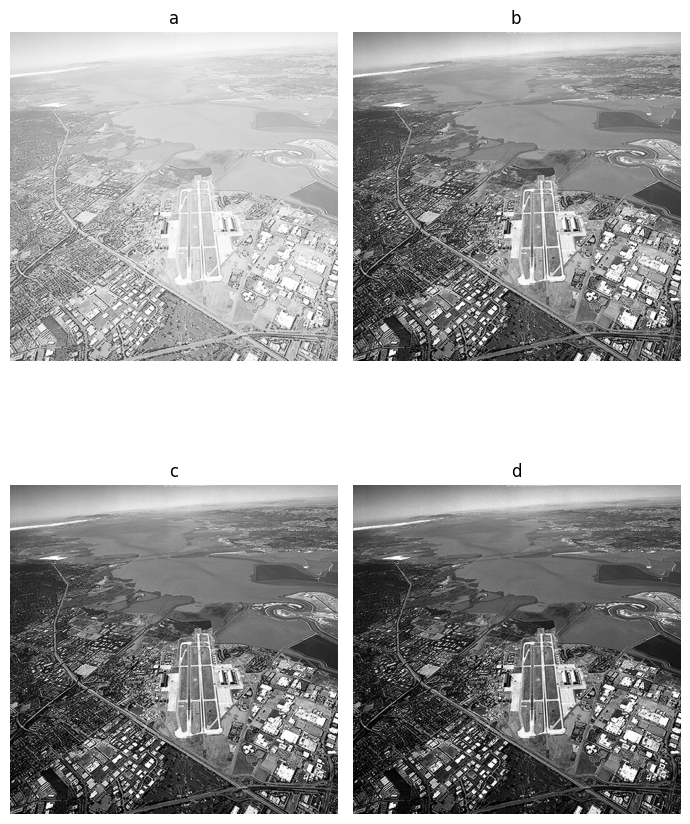

In [9]:
# Applying gamma realce

# Applying gamma realce

img_309_normalized = img_309_g_array.astype(np.float32) / 255.0 # Normalizar entre 0 e 1.

img_309_realced_3 = pot_transform_realce(c=1, r=img_309_normalized, gamma=3)
img_309_realced_4 = pot_transform_realce(c=1, r=img_309_normalized, gamma=4)
img_309_realced_5 = pot_transform_realce(c=1, r=img_309_normalized, gamma=5)

# Normalização
img_309_realced_3 = img_309_realced_3 * 255.0
img_309_realced_4 = img_309_realced_4 * 255.0
img_309_realced_5 = img_309_realced_5 * 255.0

images = [img_309, img_309_realced_3, img_309_realced_4, img_309_realced_5]

# Plot
fig, axes = plt.subplots(2, 2, figsize=(7, 10))
axes = axes.flatten()
name_figures = ["a", "b", "c", "d"]
for i, img_np in enumerate(images):
    axes[i].imshow(img_np, cmap='gray')
    axes[i].set_title(name_figures[i])
    axes[i].axis('off')
plt.tight_layout()
plt.savefig("panel_figures_3_9.tif")
plt.show()